Whisper

- 音声を transcribe
- 各ステップごとの beam 候補・スコアを記録
- 推移の可視化（matplotlib）

In [1]:

from transformers import WhisperProcessor, WhisperForConditionalGeneration
import random
import numpy as np
import torch
import torch.nn.functional as F
from whisper.decoding import BeamSearchDecoder
from whisper.tokenizer import get_tokenizer
from whisper import load_model, load_audio
from typing import Tuple
import os
import pandas as pd
import matplotlib.pyplot as plt
# ===============================
# 🔸1. 設定・ファイルパス準備
# ===============================
session_number = 1
condition = "右後ろ"
extension = "wav"

from src import get_path  # ← あなたのプロジェクト内のパス取得関数
mov_path = get_path(session_number, condition, extension)
print(f"📂 読み込みファイル: {mov_path}")

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


/usr/local/lib/python3.8/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-07-08 11:53:41.631807: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


📂 読み込みファイル: 0604data/1回目_右後ろ.wav


In [2]:

model = load_model("large-v3-turbo", device="cuda")
model.eval()

tokenizer = get_tokenizer(multilingual=True, task="transcribe")


In [3]:
from whisper.decoding import BeamSearchDecoder
from src.beam_hook import beam_update, beam_log, step

# beam関数を差し替え
BeamSearchDecoder.update = beam_update

In [4]:
# ===============================
# 🔸5. 音声読み込み・推論実行
# ===============================
audio = load_audio(str(mov_path))
result = model.transcribe(audio, beam_size=5)#,temperature=1)

print("\n=== ✅ 最終テキスト ===")
print(result["text"])


=== ✅ 最終テキスト ===
キバユソ太郎、EAS開始します。症病者発見、注意の安全確認、予視感染防御、よろしい。大丈夫ですか?大丈夫ですか?病者発見、注意の安全確認、注意の安全確認、予視感染防御、EAS開始します。横札幌を開始します。どうぞ、広告発見、注意の安全確認、予視感染防御、EAS開始します。皆さんは、皆さんは、入手してください。また、そこに戻っていってください。皆さん、お待ちしてください。ご視聴ありがとうございました。ご視聴ありがとうございました。ご視聴ありがとうございました。チャンネル登録よろしくお願いします。こちらは、ご視聴ありがとうございました。それでは、1日までご渡りを。1日までご渡りを。1日までご渡りを。1日までご渡りください。解析中です。 体に振らないでください。ショックが必要です。 充電中です。体から外れてください。ショックを実行します。 ショップが完了しました。一時中断中です。直ちに胸骨圧迫と人間呼吸をしてください。お客様なんですか?PU伏第一動画に乗せて…それがは思い産症が液体の技術前に企業は。ご視聴ありがとうございました


In [7]:
result

{'text': 'キバユソ太郎、EAS開始します。症病者発見、注意の安全確認、予視感染防御、よろしい。大丈夫ですか?大丈夫ですか?病者発見、注意の安全確認、注意の安全確認、予視感染防御、EAS開始します。横札幌を開始します。どうぞ、広告発見、注意の安全確認、予視感染防御、EAS開始します。皆さんは、皆さんは、入手してください。また、そこに戻っていってください。皆さん、お待ちしてください。ご視聴ありがとうございました。ご視聴ありがとうございました。ご視聴ありがとうございました。チャンネル登録よろしくお願いします。こちらは、ご視聴ありがとうございました。それでは、1日までご渡りを。1日までご渡りを。1日までご渡りを。1日までご渡りください。解析中です。 体に振らないでください。ショックが必要です。 充電中です。体から外れてください。ショックを実行します。 ショップが完了しました。一時中断中です。直ちに胸骨圧迫と人間呼吸をしてください。お客様なんですか?PU伏第一動画に乗せて…それがは思い産症が液体の技術前に企業は。ご視聴ありがとうございました',
 'segments': [{'id': 0,
   'seek': 0,
   'start': 0.0,
   'end': 2.2600000000000002,
   'text': 'キバユソ太郎、EAS開始します。',
   'tokens': [50365,
    15535,
    18593,
    1047,
    99,
    42668,
    9455,
    11178,
    236,
    1231,
    36,
    3160,
    21017,
    17048,
    1543,
    50478],
   'temperature': 0.0,
   'avg_logprob': -0.626889354777786,
   'compression_ratio': 1.1285714285714286,
   'no_speech_prob': 2.95193001986771e-11},
  {'id': 1,
   'seek': 0,
   'start': 11.68,
   'end': 15.280000000000001,
   'te

In [5]:

# ===============================
# 🔸6. ビームログ保存・確認
# ===============================
log_df = pd.DataFrame(beam_log)
print("\n=== 📝 Beam Log の先頭 ===")
print(log_df.head())

# ファイル保存
os.makedirs("outputs/beam_search/steps", exist_ok=True)
csv_path = f"outputs/beam_search/steps/beam_search_steps_{condition}_{session_number}.csv"
log_df.to_csv(csv_path, index=False)
print(f"✅ 保存: {csv_path}")

# ===============================
# 🔸7. 読みやすいテキスト形式で保存
# ===============================
output_lines = []

df = pd.read_csv(csv_path)
for step in sorted(df["step"].unique()):
    output_lines.append(f"Step {step}:")
    df_step = df[df["step"] == step]
    for _, row in df_step.iterrows():
        line = f"  Beam {row.beam} ← Beam {row.source_beam}: {row.prefix} + 「{row.next_token_str}」 → {row.new_seq}  (score: {row.score:.2f})"
        output_lines.append(line)
    output_lines.append("")  # 改行

# テキスト保存
txt_path = f"outputs/beam_search/steps/beam_trace_output_{condition}_{session_number}.txt"
with open(txt_path, "w", encoding="utf-8") as f:
    f.write("\n".join(output_lines))

print(f"✅ テキスト出力: {txt_path}")


=== 📝 Beam Log の先頭 ===
   step  beam  source_beam                                    prefix  \
0     0     0            0  <|startoftranscript|><|ja|><|startoflm|>   
1     0     0            0  <|startoftranscript|><|ja|><|startoflm|>   
2     0     0            0  <|startoftranscript|><|ja|><|startoflm|>   
3     0     0            0  <|startoftranscript|><|ja|><|startoflm|>   
4     0     0            0  <|startoftranscript|><|ja|><|startoflm|>   

   next_token next_token_str                                   new_seq  \
0       50365                 <|startoftranscript|><|ja|><|startoflm|>   
1       50366                 <|startoftranscript|><|ja|><|startoflm|>   
2       50367                 <|startoftranscript|><|ja|><|startoflm|>   
3       50373                 <|startoftranscript|><|ja|><|startoflm|>   
4       50371                 <|startoftranscript|><|ja|><|startoflm|>   

      score  
0 -0.078804  
1 -5.583198  
2 -5.801948  
3 -5.848823  
4 -5.852729  
✅ 保存: beam_sea

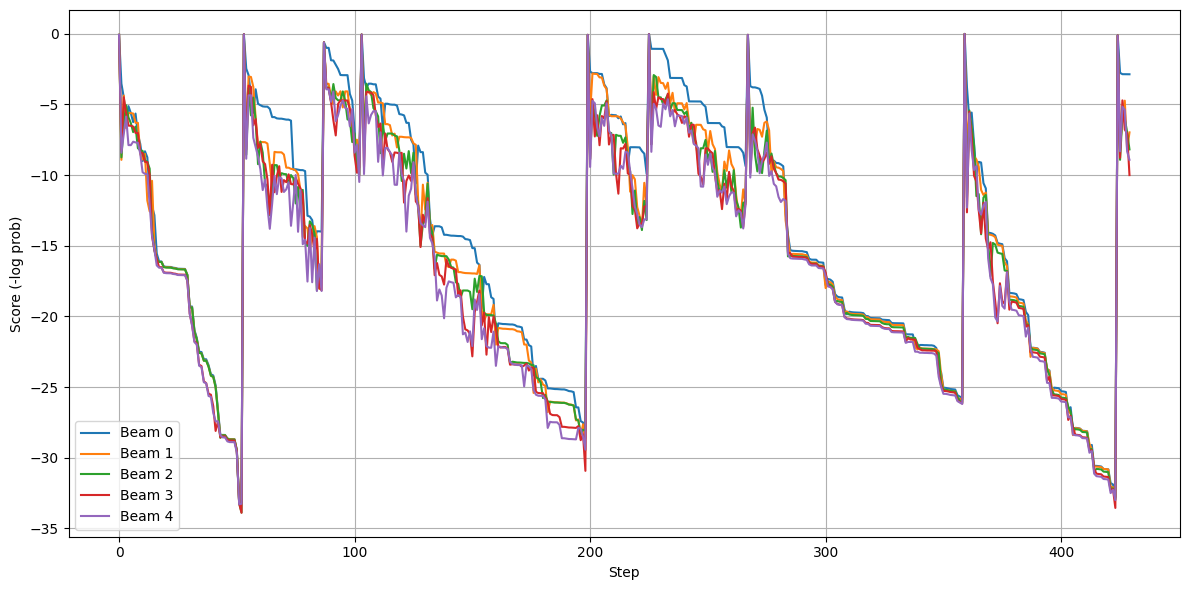

In [6]:
# ===============================
# 🔸8. スコア推移の可視化
# ===============================
# 各 step × beam ごとに最良スコアのものを抽出
best_per_beam = (
    log_df.sort_values("score", ascending=False)
    .groupby(["step", "beam"])
    .first()
    .reset_index()
)

plt.figure(figsize=(12, 6))
for beam_id in best_per_beam["beam"].unique():
    df_beam = best_per_beam[best_per_beam["beam"] == beam_id]
    plt.plot(df_beam["step"], df_beam["score"], label=f"Beam {beam_id}")

plt.xlabel("Step")
plt.ylabel("Score (-log prob)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()